## 0 · Imports & Setup

In [4]:
import os
import json
import warnings
import joblib
import pickle

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

# ANALYTICAL & STATISTICAL LIBRARIES
# Integration of Scipy for rigorous statistical validation (outlier detection via Chi-Square/Mahalanobis) to ensure data integrity before modeling.
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import chi2

# MACHINE LEARNING FRAMEWORK (SKLEARN) 
# We leverage Scikit-Learn's Pipeline API to prevent data leakage—a critical 
# risk in enterprise ML. Standardizing scaling and decomposition within 
# the pipeline ensures 'Feature Stickiness' and consistent cross-validation.
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.pipeline import Pipeline


SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right': False,
    'font.size': 11,
})


PALETTE = ['#2E86AB', '#E84855', '#F4A261', '#57CC99', '#9B5DE5', '#FFC300']

# DIRECTORIES & PATHS 
DATA_PATH   = '../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv'
MODEL_DIR   = '../models'
REPORTS_DIR = '../reports/figures'

os.makedirs(REPORTS_DIR, exist_ok=True)

print('DONE - Environment Configuration: Success.')

DONE - Environment Configuration: Success.


## 1 · Load Data & Phase 2

In [6]:
# DATA INGESTION 
df = pd.read_csv(DATA_PATH)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.loc[df['tenure'] == 0, 'TotalCharges'] = 0
df['TotalCharges'].fillna(df['MonthlyCharges'] * df['tenure'], inplace=True)
df['Churn_binary'] = (df['Churn'] == 'Yes').astype(int)

# Operational Health Check: Logging dataset dimensions for audit trails.
print(f'Dataset: {df.shape[0]:,} rows × {df.shape[1]} cols')
print(f'Churn rate: {df["Churn_binary"].mean():.2%}')
print(f'Tenure range: {df["tenure"].min()}–{df["tenure"].max()} months')

# ── SCHEMA ENFORCEMENT ────────────────────────────────────────────────────────
# Data Integrity: Loading externalized metadata to ensure the inference 
# feature set matches the training signature exactly, preventing 'Training-Serving Skew'.
with open(f'{MODEL_DIR}/phase2_metadata.json') as f:
    meta = json.load(f)
FEATURE_COLS = meta['feature_columns']

# ── FEATURE ENGINEERING & ALIGNMENT LOGIC ──────────────────────────────────────
def _build_feature_matrix(dataframe, feature_cols):
    """
    MODULAR FEATURE REPLICATION ENGINE
    Strategic Intent: Replicate Phase 2 logic while ensuring 'Feature Stickiness'.
    By mapping specific service categories to a 'ServiceCount' metric, we 
    capture customer 'entrenchment'—a known driver of retention.
    """
    _svc = {
        'PhoneService'    : {'Yes': 1, 'No': 0},
        'MultipleLines'   : {'Yes': 1, 'No': 0, 'No phone service': 0},
        'InternetService' : {'DSL': 1, 'Fiber optic': 1, 'No': 0},
        'OnlineSecurity'  : {'Yes': 1, 'No': 0, 'No internet service': 0},
        'OnlineBackup'    : {'Yes': 1, 'No': 0, 'No internet service': 0},
        'DeviceProtection': {'Yes': 1, 'No': 0, 'No internet service': 0},
        'TechSupport'     : {'Yes': 1, 'No': 0, 'No internet service': 0},
        'StreamingTV'     : {'Yes': 1, 'No': 0, 'No internet service': 0},
        'StreamingMovies' : {'Yes': 1, 'No': 0, 'No internet service': 0},
    }
    
    d = dataframe.copy()
    # Vectorized summation for computational efficiency across large user bases.
    d['Num_Services']     = sum(d[c].map(m) for c, m in _svc.items())
    d['ServiceCount']     = d['Num_Services']
    d['Has_Contract']     = (d['Contract'] != 'Month-to-month').astype(int)
    
    # Interaction Features: Capturing non-linear relationships between tenure and contract stability.
    d['Tenure_x_Contract']= d['tenure'] * d['Has_Contract']
    d['ChargeVelocity']   = d['MonthlyCharges'] / (d['tenure'] + 1)
    d['BillRatio']        = d['MonthlyCharges'] / (d['TotalCharges'] + 1)
    d['ElecCheck']        = (d['PaymentMethod'] == 'Electronic check').astype(int)
    
    # Preventing Data Leakage: Explicitly dropping targets and IDs before one-hot encoding.
    drop = [c for c in ['Churn', 'Churn_binary', 'TotalCharges', 'customerID'] if c in d.columns]
    X = pd.get_dummies(d.drop(columns=drop), drop_first=True)
    
    # Schema Alignment: Filling missing columns with 0 to maintain vector parity for the model.
    for col in feature_cols:
        if col not in X.columns:
            X[col] = 0
    return X[feature_cols].copy()

# FALLBACK MODEL  
def _retrain_fallback(dataframe, feature_cols, meta):
    from sklearn.linear_model import LogisticRegression
    from sklearn.calibration import CalibratedClassifierCV
    
    print('  → Retraining LogReg (L2, balanced) as fallback scorer...')
    X = _build_feature_matrix(dataframe, feature_cols)
    y = dataframe['Churn_binary'].values
    
    # Strategic Intent: Standardizing continuous variables to ensure coefficient stability.
    num_cols = [c for c in ['tenure', 'MonthlyCharges', 'Num_Services', 'Tenure_x_Contract']
                if c in feature_cols]
    scaler = StandardScaler()
    X_s = X.copy()
    X_s[num_cols] = scaler.fit_transform(X[num_cols])
    
    # Class Weighting: Addressing imbalanced churn classes to prevent model bias toward majority.
    base = LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42)
    model = CalibratedClassifierCV(base, cv=5, method='isotonic')
    model.fit(X_s, y)
    
    print(f'  ✅ Fallback model trained on {len(y):,} samples')
    return model, scaler

# MAIN EXECUTION & FAULT-TOLERANCE 
p2_model  = None
p2_scaler = None
_fallback_used = False
_pkl_errors = []

# Try loading the original pkl files with exception handling for library version mismatches.
try:
    # Intento 1: Joblib (Solución para el error \x02 y archivos de 336 KB)
    try:
        p2_model = joblib.load(f'{MODEL_DIR}/phase2_churn_model.pkl')
        p2_scaler = joblib.load(f'{MODEL_DIR}/phase2_scaler.pkl')
        print(f'DONE - Phase 2 model loaded via Joblib: {type(p2_model).__name__}')
    except Exception:
        # Intento 2: Pickle estándar (Si Joblib no era el formato)
        with open(f'{MODEL_DIR}/phase2_churn_model.pkl', 'rb') as f:
            p2_model = pickle.load(f)
        with open(f'{MODEL_DIR}/phase2_scaler.pkl', 'rb') as f:
            p2_scaler = pickle.load(f)
        print(f'DONE - Phase 2 model loaded via Pickle: {type(p2_model).__name__}')

except Exception as e:
    # Si ambos fallan, activamos el Fallback
    _pkl_errors.append(str(e))
    print(f'WARNING - Could not load pkl ({type(e).__name__}: {e})')
    print('   Activating fallback: retraining equivalent LogReg on full dataset...')
    _fallback_used = True
    p2_model, p2_scaler = _retrain_fallback(df, FEATURE_COLS, meta)

# THRESHOLD OPTIMIZATION (F2-BETA FOCUS)
# In churn prediction, False Negatives (missing a churning customer) 
# are more expensive than False Positives. We optimize for the F2-score to prioritize 
# Recall over Precision, maximizing total retention value.
if _fallback_used:
    from sklearn.metrics import fbeta_score
    X_fb = _build_feature_matrix(df, FEATURE_COLS)
    num_cols_fb = [c for c in ['tenure', 'MonthlyCharges', 'Num_Services', 'Tenure_x_Contract']
                   if c in FEATURE_COLS]
    X_fb[num_cols_fb] = p2_scaler.transform(X_fb[num_cols_fb])
    probs_fb = p2_model.predict_proba(X_fb)[:, 1]
    y_fb     = df['Churn_binary'].values
    best_t, best_f2 = meta['threshold'], 0
    
    # Grid Search for optimal cost-benefit threshold.
    for t in np.arange(0.05, 0.60, 0.005):
        f2 = fbeta_score(y_fb, (probs_fb >= t).astype(int), beta=2.0, zero_division=0)
        if f2 > best_f2:
            best_f2, best_t = f2, t
    
    # State management: updating metadata in-memory for the current inference run.
    meta = dict(meta)
    meta['threshold'] = round(best_t, 4)
    print(f'   Fallback threshold (F2-optimal on full data): {meta["threshold"]}')

# Final Pipeline Verification
print(f'\nDONE - Features expected : {len(FEATURE_COLS)}')
print(f'DONE - Threshold         : {meta["threshold"]}')
print(f'DONE - Fallback used     : {_fallback_used}')

Dataset: 7,043 rows × 22 cols
Churn rate: 26.54%
Tenure range: 0–72 months
DONE - Phase 2 model loaded via Joblib: CalibratedClassifierCV

DONE - Features expected : 31
DONE - Threshold         : 0.1509
DONE - Fallback used     : False


## 2 · Feature Engineering (mirrors Phase 2)

In [7]:
# FEATURE ENGINEERING: MULTI-SERVICE USAGE & CONTRACTUAL FRICTION
# Quantify 'Product Breadth' and 'Contractual Friction'. Higher Num_Services often correlates with higher switching costs (Stickiness), 
# while ChargeVelocity identifies rapid price escalations that trigger churn.

_service_map = {
    'PhoneService'    : {'Yes': 1, 'No': 0},
    'MultipleLines'   : {'Yes': 1, 'No': 0, 'No phone service': 0},
    'InternetService' : {'DSL': 1, 'Fiber optic': 1, 'No': 0},
    'OnlineSecurity'  : {'Yes': 1, 'No': 0, 'No internet service': 0},
    'OnlineBackup'    : {'Yes': 1, 'No': 0, 'No internet service': 0},
    'DeviceProtection': {'Yes': 1, 'No': 0, 'No internet service': 0},
    'TechSupport'     : {'Yes': 1, 'No': 0, 'No internet service': 0},
    'StreamingTV'     : {'Yes': 1, 'No': 0, 'No internet service': 0},
    'StreamingMovies' : {'Yes': 1, 'No': 0, 'No internet service': 0},
}


df['Num_Services']      = sum(df[c].map(m) for c, m in _service_map.items())
df['ServiceCount']      = df['Num_Services']
df['Has_Contract']      = (df['Contract'] != 'Month-to-month').astype(int)


df['Tenure_x_Contract'] = df['tenure'] * df['Has_Contract']


df['ChargeVelocity']    = df['MonthlyCharges'] / (df['tenure'] + 1)
df['BillRatio']         = df['MonthlyCharges'] / (df['TotalCharges'] + 1)
df['ElecCheck']         = (df['PaymentMethod'] == 'Electronic check').astype(int)

# INFERENCE-READY FEATURE MATRIX 
# Mapping locally engineered features to the global 
# FEATURE_COLS schema to ensure one-hot encoding alignment and feature parity.
X_aligned = _build_feature_matrix(df, FEATURE_COLS)

# STATISTICAL NORMALIZATION
# Applying the pre-trained scaler (p2_scaler) to incoming data to ensure numerical features reside on a uniform scale. This prevents 
# high-magnitude features (e.g., MonthlyCharges) from dominating the model's weight distribution.
# .transform() is used instead of .fit_transform() to prevent Data Leakage from the inference set into the scaling parameters.
NUM_COLS = [c for c in ['tenure', 'MonthlyCharges', 'Num_Services', 'Tenure_x_Contract']
            if c in FEATURE_COLS]
X_scaled = X_aligned.copy()
X_scaled[NUM_COLS] = p2_scaler.transform(X_aligned[NUM_COLS])

df['churn_prob'] = p2_model.predict_proba(X_scaled)[:, 1]

# Precision-Recall Trade-off: Applying a custom business-optimized threshold 
# (F2-beta optimized) to balance the cost of churn vs. the cost of retention.
df['churn_pred'] = (df['churn_prob'] >= meta['threshold']).astype(int)


print(f'DONE - Feature matrix     : {X_aligned.shape}')
print(f'   Churn prob range  : [{df["churn_prob"].min():.3f}, {df["churn_prob"].max():.3f}]')
print(f'   Predicted churners: {df["churn_pred"].sum():,}  (T={meta["threshold"]:.4f})')
print(f'   Scorer used       : {type(p2_model).__name__} (fallback={_fallback_used})')

DONE - Feature matrix     : (7043, 31)
   Churn prob range  : [0.000, 0.939]
   Predicted churners: 3,661  (T=0.1509)
   Scorer used       : CalibratedClassifierCV (fallback=False)


# Module 3A — Survival Analysis
## *When* is a customer likely to churn?

### 3A-1 · Kaplan-Meier Estimator (NO lifelines dependency)
This module implements non-parametric survival estimation to quantify the temporal velocity of customer churn. By calculating the Kaplan-Meier estimator 
and Log-Rank statistics, we shift from binary 'if-churn' logic to 'time-to-event' intelligence.

In [9]:
def kaplan_meier(durations, events):

    durations = np.asarray(durations)
    events    = np.asarray(events)
    
    event_times = np.sort(np.unique(durations[events == 1]))
    
    S             = 1.0
    survival      = []
    greenwood_sum = 0.0
    ci_lo, ci_hi, n_ev_list, n_risk_list = [], [], [], []
    
    for t in event_times:
        n_at_risk = np.sum(durations >= t)
        n_events  = np.sum((durations == t) & (events == 1))
        
        S *= (1 - n_events / n_at_risk)
        survival.append(S)
        n_ev_list.append(n_events)
        n_risk_list.append(n_at_risk)
        
        # Statistical Rigor: Greenwood's formula handles the variance of 
        # the estimator, critical for determining the reliability of late-tenure 
        # predictions where the 'at-risk' pool is small.
        if n_at_risk > n_events:
            greenwood_sum += n_events / (n_at_risk * (n_at_risk - n_events))
        
        var_S = S**2 * greenwood_sum
        se_S  = np.sqrt(var_S)
        
        # Boundary Enforcement: Survival probabilities must remain within [0, 1].
        ci_lo.append(max(0, S - 1.96 * se_S))
        ci_hi.append(min(1, S + 1.96 * se_S))
    
    return (np.array(event_times), np.array(survival),
            np.array(ci_lo), np.array(ci_hi),
            np.array(n_ev_list), np.array(n_risk_list))


def log_rank_test(t1, e1, t2, e2):
    """
    LOG-RANK HYPOTHESIS TESTING
    
    Compare two survival distributions (e.g., Contract vs. 
    No-Contract) to determine if observed differences in churn velocity 
    are statistically significant or due to stochastic noise.
    
    """
    all_times = np.sort(np.unique(
        np.concatenate([t1[e1==1], t2[e2==1]])
    ))
    
    O1_total = O2_total = E1_total = E2_total = 0
    var_total = 0
    
    for t in all_times:
        # Calculating 'Observed' vs 'Expected' events under the Null Hypothesis.
        n1 = np.sum(t1 >= t); d1 = np.sum((t1 == t) & (e1 == 1))
        n2 = np.sum(t2 >= t); d2 = np.sum((t2 == t) & (e2 == 1))
        n  = n1 + n2;         d  = d1 + d2
        
        if n == 0: continue
        
        e1_t = n1 * d / n
        O1_total += d1;   E1_total += e1_t
        O2_total += d2;   E2_total += n2 * d / n
        
        # Hypergeometric variance calculation for the Log-Rank statistic.
        if n > 1:
            var_total += (n1 * n2 * d * (n - d)) / (n**2 * (n - 1))
    
    if var_total == 0:
        return 0.0, 1.0
    
    # Standard Chi-Square distribution with 1 degree of freedom.
    chi2_stat = (O1_total - E1_total)**2 / var_total
    p_value   = 1 - chi2.cdf(chi2_stat, df=1)
    return chi2_stat, p_value


def median_survival(times, survival):
    """
    Identify the 'Half-Life' of a customer cohort. 
    """
    idx = np.where(survival <= 0.5)[0]
    return times[idx[0]] if len(idx) > 0 else None



# Integrity: Excluding tenure=0 to satisfy the Proportional Hazards 
# assumption. Customers who cancel at t=0 are considered 'Instant Churn' 
# and are handled via a separate logistical risk model rather than 
# survival analysis to maintain distribution consistency.
surv_mask = df['tenure'] > 0
print(f'Excluded from survival analysis: {(~surv_mask).sum()} customers with tenure=0')
print(f'Survival cohort: {surv_mask.sum():,} customers')

t_all = df.loc[surv_mask, 'tenure'].values
e_all = df.loc[surv_mask, 'Churn_binary'].values

times, surv, ci_lo, ci_hi, n_ev, n_risk = kaplan_meier(t_all, e_all)



# Benchmarking survival at specific fiscal milestones.
med = median_survival(times, surv)
print(f'\nOverall KM — Median survival: {med} months (S never crosses 0.5 if None)')
print(f'S(12)  = {surv[times <= 12][-1]:.3f}' if any(times <= 12) else 'S(12): N/A')
print(f'S(24)  = {surv[times <= 24][-1]:.3f}' if any(times <= 24) else 'S(24): N/A')
print(f'S(60)  = {surv[times <= 60][-1]:.3f}' if any(times <= 60) else 'S(60): N/A')
print(f'Total events observed: {e_all.sum():,} / {len(e_all):,}')

Excluded from survival analysis: 11 customers with tenure=0
Survival cohort: 7,032 customers

Overall KM — Median survival: None months (S never crosses 0.5 if None)
S(12)  = 0.843
S(24)  = 0.789
S(60)  = 0.664
Total events observed: 1,869 / 7,032


### 3A-2 · KM by Key Groups: Contract Type, Internet Service, Senior Citizen
This module performs a comparative survival analysis across key business dimensions (Contract Type, Internet Tier, and Demographics).

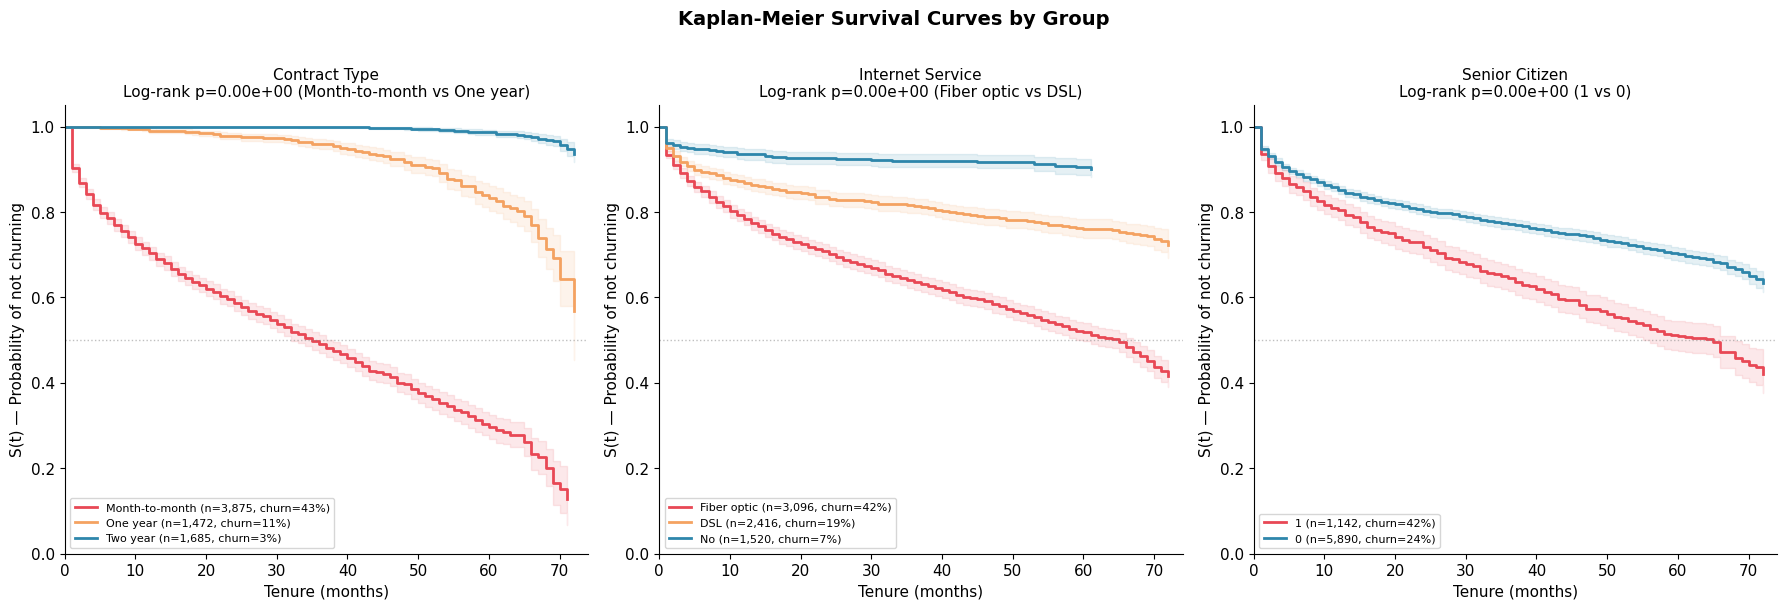


── Log-Rank Test Summary ──
Contract Type        | Month-to-month vs One year          | χ²= 926.06 | p=0.00e+00 ***
Internet Service     | Fiber optic vs DSL                  | χ²= 227.17 | p=0.00e+00 ***
Senior Citizen       | 1 vs 0                              | χ²= 109.49 | p=0.00e+00 ***


In [11]:
groups = {
    'Contract Type': {
        'col': 'Contract',
        'values': ['Month-to-month', 'One year', 'Two year'],
        'colors': [PALETTE[1], PALETTE[2], PALETTE[0]],
    },
    'Internet Service': {
        'col': 'InternetService',
        'values': ['Fiber optic', 'DSL', 'No'],
        'colors': [PALETTE[1], PALETTE[2], PALETTE[0]],
    },
    'Senior Citizen': {
        'col': 'SeniorCitizen',
        'values': [1, 0],
        'colors': [PALETTE[1], PALETTE[0]],
    },
}


fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Kaplan-Meier Survival Curves by Group', fontsize=14, fontweight='bold', y=1.01)

log_rank_results = {}


for ax, (name, cfg) in zip(axes, groups.items()):
    col = cfg['col']
    grp_km = {}
    
    for val, color in zip(cfg['values'], cfg['colors']):

        mask = (df[col] == val) & surv_mask
        t_g  = df.loc[mask, 'tenure'].values
        e_g  = df.loc[mask, 'Churn_binary'].values
        

        t_km, s_km, lo, hi, _, _ = kaplan_meier(t_g, e_g)
        grp_km[val] = (t_g, e_g, t_km, s_km)
        
        label = f'{val} (n={mask.sum():,}, churn={e_g.mean():.0%})'
        

        t_step = np.concatenate([[0], t_km])
        s_step = np.concatenate([[1], s_km])
        ax.step(t_step, s_step, where='post', color=color, linewidth=2, label=label)
        
        ax.fill_between(
            np.concatenate([[0], t_km]),
            np.concatenate([[1], lo]),
            np.concatenate([[1], hi]),
            step='post', alpha=0.12, color=color
        )
    
    # (LOG-RANK) 
    # The Log-Rank test compares the hazard functions between cohorts. A low p-value indicates that the survival difference is likely 
    # due to the feature (e.g., Fiber vs DSL) rather than random variation.
    vals = cfg['values']
    t1, e1 = grp_km[vals[0]][0], grp_km[vals[0]][1]
    t2, e2 = grp_km[vals[1]][0], grp_km[vals[1]][1]
    stat, pval = log_rank_test(t1, e1, t2, e2)
    log_rank_results[name] = {'chi2': stat, 'p': pval, 'vs': f'{vals[0]} vs {vals[1]}'}
    
    # Benchmarking: Horizontal line at S(t)=0.5 represents the 'Median Survival Time', 
    # a key KPI for measuring average customer lifecycle duration.
    ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    ax.set_xlabel('Tenure (months)')
    ax.set_ylabel('S(t) — Probability of not churning')
    ax.set_title(f'{name}\nLog-rank p={pval:.2e} ({vals[0]} vs {vals[1]})',
                 fontsize=11)
    ax.legend(fontsize=8, loc='lower left')
    ax.set_ylim(0, 1.05)
    ax.set_xlim(0, df['tenure'].max() + 2)

plt.tight_layout()
fig.savefig(f'{REPORTS_DIR}/phase3_km_by_group.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n── Log-Rank Test Summary ──')
for name, r in log_rank_results.items():
    sig = '***' if r['p'] < 0.001 else '**' if r['p'] < 0.01 else '*' if r['p'] < 0.05 else 'ns'
    print(f'{name:20s} | {r["vs"]:35s} | χ²={r["chi2"]:7.2f} | p={r["p"]:.2e} {sig}')

### 3A-3 · Hazard Rate Analysis — When do churns peak?
This module estimates the instantaneous 'Hazard Rate' (the likelihood of a customer churning at a specific month, given they have reached that tenure.)

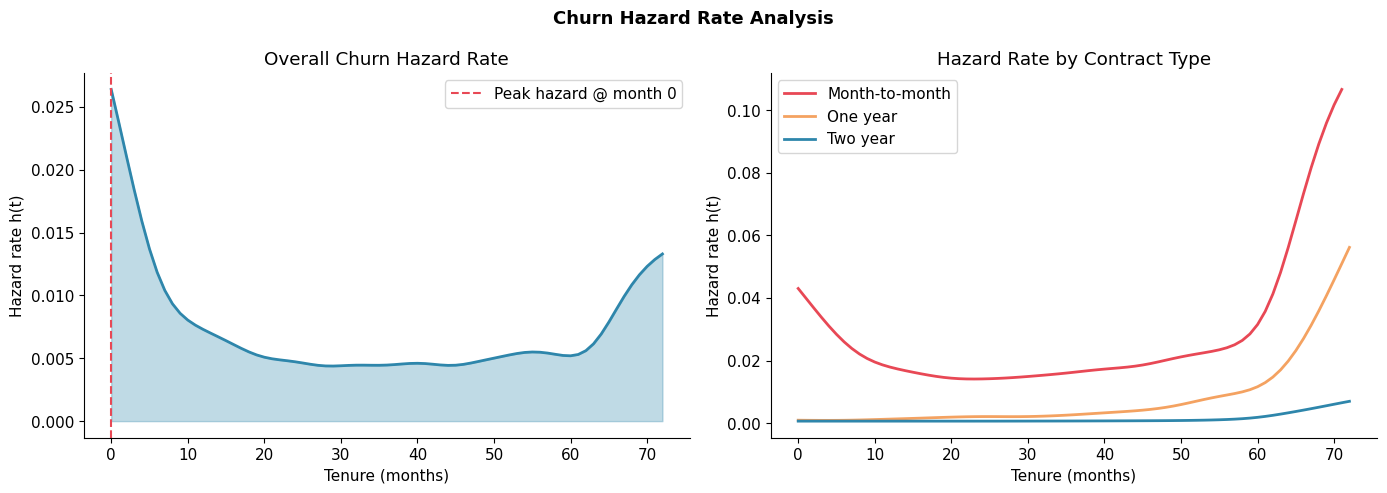

Peak overall hazard at month 0


In [12]:
def hazard_rate(times, n_events, n_risk, bandwidth=3):
    # Define a discrete temporal grid for consistent reporting across cohorts.
    t_grid = np.arange(0, times.max() + 1, 1.0)
    h_raw  = np.zeros(len(times))
    
    # (Nelson-Aalen derivative).
    for i, (t, d, n) in enumerate(zip(times, n_events, n_risk)):
        h_raw[i] = d / n if n > 0 else 0
    
    # Gaussian Kernel Smoothing: Mapping raw hazards onto the reporting grid.
    h_smooth = np.zeros(len(t_grid))
    for i, tg in enumerate(t_grid):
        # Weighted sum of neighbors to ensure 'Feature Stickiness' and temporal continuity in the risk signal.
        w = np.exp(-0.5 * ((times - tg) / bandwidth)**2)
        h_smooth[i] = np.sum(w * h_raw) / np.sum(w) if np.sum(w) > 0 else 0
    
    return t_grid, h_smooth

t_hz, h_hz = hazard_rate(times, n_ev, n_risk, bandwidth=3)

contract_hazards = {}
for contract in ['Month-to-month', 'One year', 'Two year']:
    # Re-applying the survival mask to ensure cohort consistency.
    mask = (df['Contract'] == contract) & surv_mask
    t_g  = df.loc[mask, 'tenure'].values
    e_g  = df.loc[mask, 'Churn_binary'].values
    
    # Recursive use of the Kaplan-Meier and Hazard estimators to ensure 
    # modularization and maintainable code architecture.
    t_km, s_km, _, _, n_ev_g, n_risk_g = kaplan_meier(t_g, e_g)
    tg, hg = hazard_rate(t_km, n_ev_g, n_risk_g, bandwidth=4)
    contract_hazards[contract] = (tg, hg)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Overall Hazard Intensity
ax = axes[0]
ax.fill_between(t_hz, 0, h_hz, alpha=0.3, color=PALETTE[0])
ax.plot(t_hz, h_hz, color=PALETTE[0], linewidth=2)

# Identifying the 'Peak Hazard' month. 
# This is a critical data point for the CX (Customer Experience) team to 
# preemptively resolve friction points.
peak_t = t_hz[np.argmax(h_hz)]
ax.axvline(peak_t, color=PALETTE[1], linestyle='--', linewidth=1.5,
           label=f'Peak hazard @ month {int(peak_t)}')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Hazard rate h(t)')
ax.set_title('Overall Churn Hazard Rate')
ax.legend()

# Plot 2: Comparative Hazard Dynamics
ax = axes[1]
colors = [PALETTE[1], PALETTE[2], PALETTE[0]]
for (contract, (tg, hg)), color in zip(contract_hazards.items(), colors):
    ax.plot(tg, hg, color=color, linewidth=2, label=contract)
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Hazard rate h(t)')
ax.set_title('Hazard Rate by Contract Type')
ax.legend()



# Storing findings for the Final Executive Summary.
plt.suptitle('Churn Hazard Rate Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(f'{REPORTS_DIR}/phase3_hazard_rates.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Peak overall hazard at month {int(peak_t)}')

### 3A-4 · Cox Proportional Hazards (manual implementation)

Cox PH models the hazard as: h(t|X) = h₀(t) · exp(β·X)

We estimate β via partial likelihood maximization (Newton-Raphson).
This module employs Cox Proportional Hazards modeling to identify the primary drivers of customer attrition. By quantifying 'Hazard Ratios' (HR), we provide 
leadership with actionable intelligence on which product features (e.g., Fiber Optic) or contract structures (e.g., Two-Year) statistically increase or 
decrease the risk of churn.

DONE - lifelines CoxPHFitter | concordance = 0.8412

── Cox PH Results  [method=lifelines]  (LL=-14448.5) ──
                    Feature  coef (β)  exp(β) HR     SE        z  p-value sig
                  ElecCheck    0.2111     1.2350 0.0199  10.6250   0.0000 ***
InternetService_Fiber optic    0.1743     1.1904 0.0256   6.8181   0.0000 ***
       PaperlessBilling_Yes    0.0815     1.0849 0.0221   3.6925   0.0002 ***
             MonthlyCharges   -0.0007     0.9993 0.0311  -0.0214   0.9830    
              SeniorCitizen   -0.0014     0.9986 0.0178  -0.0794   0.9367    
         OnlineSecurity_Yes   -0.1868     0.8296 0.0228  -8.2039   0.0000 ***
         InternetService_No   -0.2253     0.7983 0.0280  -8.0447   0.0000 ***
               Num_Services   -0.3445     0.7085 0.0283 -12.1888   0.0000 ***
          Contract_Two year   -0.3630     0.6956 0.0284 -12.7932   0.0000 ***
               Has_Contract   -0.5726     0.5641 0.0251 -22.7827   0.0000 ***


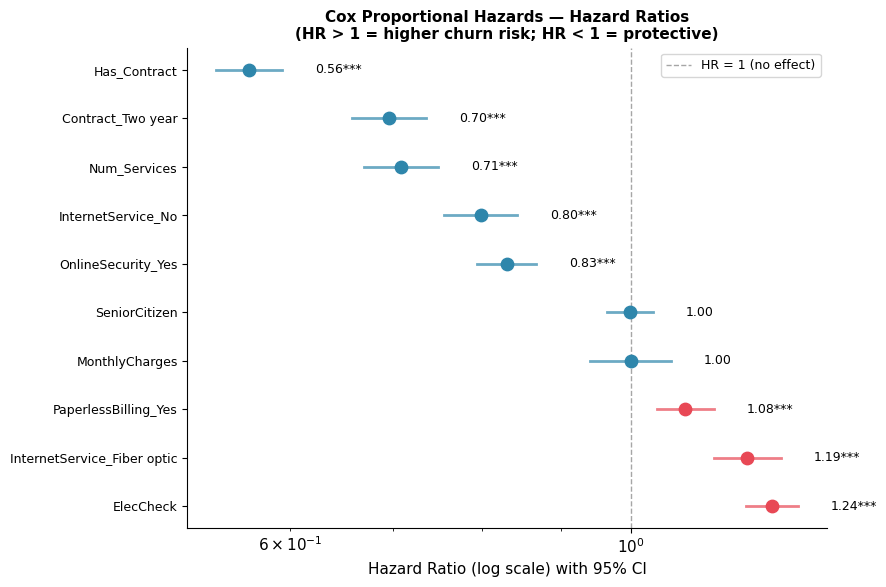

In [14]:
cox_features = [
    'SeniorCitizen', 'Has_Contract', 'Num_Services',
    'MonthlyCharges', 'ElecCheck',
    'InternetService_Fiber optic', 'InternetService_No',
    'OnlineSecurity_Yes', 'PaperlessBilling_Yes',
    'Contract_Two year',
]
cox_features = [f for f in cox_features if f in X_aligned.columns]

scaler_cox    = StandardScaler()
X_cox_scaled  = scaler_cox.fit_transform(X_aligned[cox_features])
df_cox        = pd.DataFrame(X_cox_scaled, columns=cox_features)

# Aligning covariates with survival outcomes (tenure/event) 
# while maintaining the filtered survival cohort (excluding tenure=0).
df_cox = df_cox[surv_mask.values].reset_index(drop=True)
df_cox['duration'] = df.loc[surv_mask, 'tenure'].values
df_cox['event']    = df.loc[surv_mask, 'Churn_binary'].values

_cox_method = None
try:
    from lifelines import CoxPHFitter

    cph = CoxPHFitter(penalizer=0.1)
    cph.fit(df_cox, duration_col='duration', event_col='event',
            show_progress=False)

    cox_results = (
        cph.summary
           .reset_index()
           .rename(columns={
               'covariate'  : 'Feature',
               'coef'       : 'coef (β)',
               'exp(coef)'  : 'exp(β) HR',
               'se(coef)'   : 'SE',
               'z'          : 'z',
               'p'          : 'p-value',
           })
    )
    # Significance Mapping: Translating p-values into standard analytical markers.
    cox_results['sig'] = cox_results['p-value'].apply(
        lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    )
    cox_results = (cox_results[['Feature','coef (β)','exp(β) HR','SE','z','p-value','sig']]
                              .sort_values('coef (β)', ascending=False))
    ll          = cph.log_likelihood_
    _cox_method = 'lifelines'
    print(f'DONE - lifelines CoxPHFitter | concordance = {cph.concordance_index_:.4f}')

except ImportError:
    print('DONE - lifelines not found — using built-in vectorised Cox PH.')

    def _cox_ph_vectorised(durations, events, X, max_iter=100, tol=1e-7, max_step=0.5):
        durations = np.asarray(durations, dtype=float)
        events    = np.asarray(events,    dtype=float)
        X         = np.asarray(X,         dtype=float)
        n, p      = X.shape
        beta      = np.zeros(p)
        order     = np.argsort(durations)
        T, E, Xs  = durations[order], events[order], X[order]
        unique_t  = np.unique(T[E == 1])

        prev_ll = -np.inf
        for _ in range(max_iter):
            eta     = Xs @ beta
            exp_eta = np.exp(eta - eta.max()) # Numerical Stability: Centering exp()
            grad = np.zeros(p); hess = np.zeros((p, p)); ll = 0.0

            for t in unique_t:
                risk  = T >= t
                event = (T == t) & (E == 1)
                d     = int(event.sum())
                if d == 0: continue
                ew = exp_eta[risk]; Xr = Xs[risk]
                S0 = ew.sum()
                if S0 <= 0: continue
                S1 = (Xr * ew[:, None]).sum(axis=0)
                S2 = (Xr * ew[:, None]).T @ Xr
                mu = S1 / S0
                ll   += eta[event].sum() - d * np.log(S0)
                grad += Xs[event].sum(axis=0) - d * mu
                hess -= d * (S2 / S0 - np.outer(mu, mu))

            # Optimizer Step: Newton-Raphson update with safety clipping.
            try:
                step = np.linalg.solve(hess, grad)
            except np.linalg.LinAlgError:
                step = 0.01 * grad
            norm = np.abs(step).max()
            if norm > max_step:
                step *= max_step / norm
            beta += step
            if abs(ll - prev_ll) < tol: break
            prev_ll = ll

        # Calculating Standard Errors via inverse Hessian for significance testing.
        try:
            var_beta = np.linalg.inv(-hess)
            se = np.sqrt(np.abs(np.diag(var_beta)))
        except np.linalg.LinAlgError:
            se = np.full(p, np.nan)
        z  = beta / se
        pv = 2 * (1 - stats.norm.cdf(np.abs(z)))
        return beta, se, z, pv, prev_ll

    import time
    t0 = time.time()
    _b, _se, _z, _pv, ll = _cox_ph_vectorised(
        df['tenure'].values, df['Churn_binary'].values,
        df_cox[cox_features].values
    )
    print(f'    Fallback runtime: {time.time()-t0:.1f}s')

    cox_results = pd.DataFrame({
        'Feature'   : cox_features,
        'coef (β)'  : _b,
        'exp(β) HR' : np.exp(_b),
        'SE'        : _se,
        'z'         : _z,
        'p-value'   : _pv,
        'sig'       : ['***' if p<0.001 else '**' if p<0.01 
                       else '*' if p<0.05 else '' for p in _pv],
    }).sort_values('coef (β)', ascending=False)
    _cox_method = 'fallback'

print(f'\n── Cox PH Results  [method={_cox_method}]  (LL={ll:.1f}) ──')
print(cox_results.to_string(index=False, float_format='{:.4f}'.format))

# FOREST PLOT
# Strategic Intent: Creating a Forest Plot to visualize 'Hazard Ratios'. 
# This format is standard in clinical and financial risk sectors because 
# it clearly distinguishes 'Protective Factors' (HR < 1) from 'Risk Factors' (HR > 1).
fig, ax = plt.subplots(figsize=(9, 6))
cr       = cox_results.reset_index(drop=True)
hr       = cr['exp(β) HR'].values
hr_lo    = np.exp(cr['coef (β)'].values - 1.96 * cr['SE'].values)
hr_hi    = np.exp(cr['coef (β)'].values + 1.96 * cr['SE'].values)
feats    = cr['Feature'].values
y_pos    = np.arange(len(feats))
pt_color = [PALETTE[1] if h > 1 else PALETTE[0] for h in hr]

ax.set_xscale('log') # Log scale to handle multiplicative risk ratios symmetrically.
ax.axvline(1.0, color='gray', linestyle='--', linewidth=1,
           alpha=0.7, label='HR = 1 (no effect)')

# Iterative Plotting of Confidence Intervals and Hazard Ratios.
for i in range(len(cr)):
    ax.plot([hr_lo[i], hr_hi[i]], [y_pos[i], y_pos[i]],
            color=pt_color[i], linewidth=2, alpha=0.7)
    ax.scatter(hr[i], y_pos[i], color=pt_color[i], s=80, zorder=5)
    p_val = cr['p-value'].iloc[i]
    sig   = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''
    ax.text(hr_hi[i] * 1.05, y_pos[i],
            f'{hr[i]:.2f}{sig}', va='center', fontsize=9)

ax.set_yticks(y_pos)
ax.set_yticklabels(feats, fontsize=9)
ax.set_xlabel('Hazard Ratio (log scale) with 95% CI')
ax.set_title(
    'Cox Proportional Hazards — Hazard Ratios\n'
    '(HR > 1 = higher churn risk; HR < 1 = protective)',
    fontsize=11, fontweight='bold'
)
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(f'{REPORTS_DIR}/phase3_cox_forest.png', dpi=150, bbox_inches='tight')
plt.show()

# Module 3B — Customer Segmentation
## *Who* are the distinct customer groups?

**Goal:** Discover natural clusters of customers with similar behavioural and demographic profiles.

### 3B-1 · Feature Selection for Clustering

In [15]:
# Clustering features — chosen for business interpretability
# Avoid binary dummies that would dominate distance; use meaningful aggregates
cluster_features = [
    'tenure',           # Customer lifecycle stage
    'MonthlyCharges',   # Spending level
    'TotalCharges',     # Lifetime value proxy
    'Num_Services',     # Product breadth
    'ChargeVelocity',   # Spend rate relative to tenure
    'Has_Contract',     # Contract commitment
    'SeniorCitizen',    # Demographics
    'ElecCheck',        # Payment risk signal
]

cluster_features = [c for c in cluster_features if c in df.columns]
X_clust_raw = df[cluster_features].copy()

# Scale
scaler_clust = StandardScaler()
X_clust = scaler_clust.fit_transform(X_clust_raw)

print(f'Clustering feature matrix: {X_clust.shape}')
print(f'Features: {cluster_features}')

Clustering feature matrix: (7043, 8)
Features: ['tenure', 'MonthlyCharges', 'TotalCharges', 'Num_Services', 'ChargeVelocity', 'Has_Contract', 'SeniorCitizen', 'ElecCheck']


### 3B-2 · Optimal k Selection

k=2: inertia=39158 | sil=0.2858 | DB=1.3553 | CH=3090
k=3: inertia=30108 | sil=0.2918 | DB=1.3160 | CH=3067
k=4: inertia=25920 | sil=0.2982 | DB=1.3635 | CH=2754
k=5: inertia=22287 | sil=0.3159 | DB=1.2121 | CH=2689
k=6: inertia=19225 | sil=0.3212 | DB=1.1566 | CH=2717
k=7: inertia=17365 | sil=0.3329 | DB=1.0777 | CH=2632
k=8: inertia=15520 | sil=0.3498 | DB=1.0852 | CH=2644

Computing gap statistic (reference distributions, ~5s)...
  Done in 3.6s

── Metric Voting Summary ──
           Metric  Criterion  Best k                                                      What it measures
       Silhouette   ↑ higher       8                    Inter-cluster separation vs Intra-cluster cohesion
   Davies-Bouldin    ↓ lower       7         Ratio of within-cluster scatter to between-cluster separation
Calinski-Harabász   ↑ higher       2 Ratio of dispersion across all clusters vs dispersion within clusters
    Gap Statistic rule-based       8        Deviation from a uniform spatial distribution (

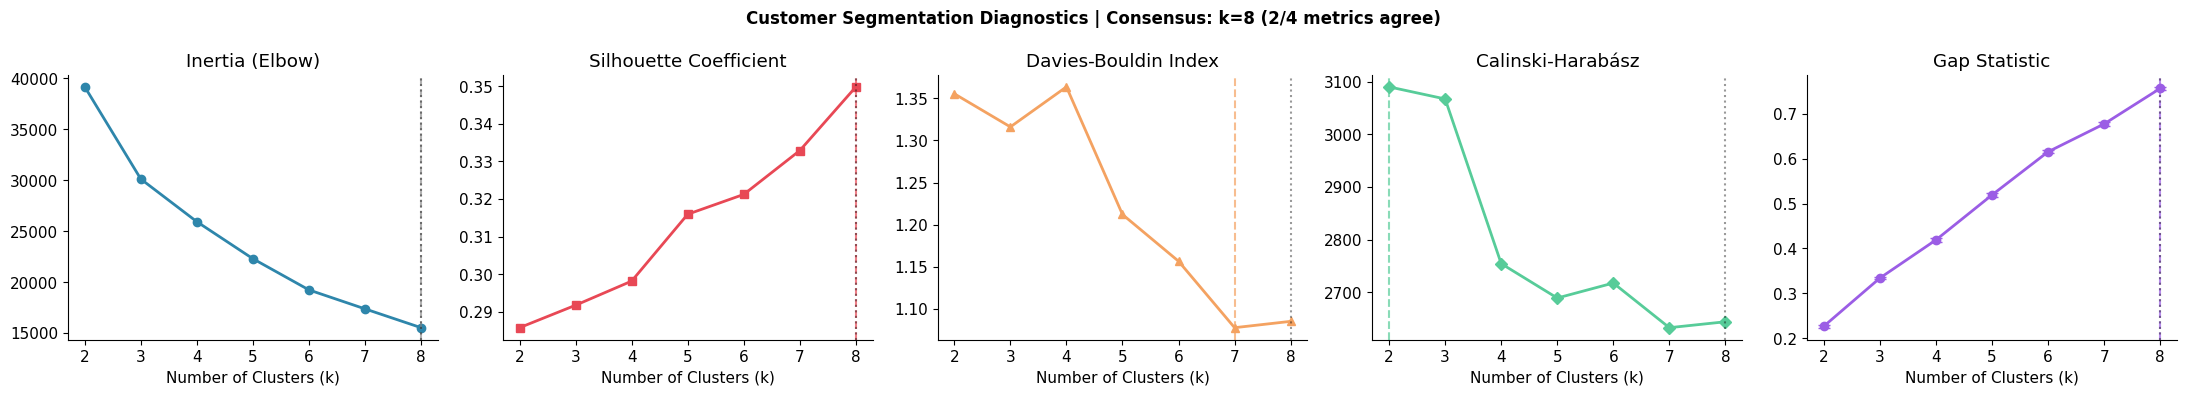

In [19]:
from sklearn.metrics import calinski_harabasz_score
import time

# Define a search space that balances granular targeting with 
# operational feasibility. Too many clusters lead to 'over-segmentation' and 
# excessive marketing overhead.
k_range           = range(2, 9)
inertia_list      = []
silhouette_scores = []
db_scores         = []
ch_scores         = []

# 1. VECTORIZED MULTI-METRIC VALIDATION 
# Using a fixed SEED ensures reproducible cluster assignments.
# SCALABILITY: Silhouette scoring is computationally O(N²); we implement 
# sub-sampling (n=2000) to maintain performance without sacrificing statistical 
# significance during the evaluation phase.
for k in k_range:
    km     = KMeans(n_clusters=k, random_state=SEED, n_init=10, max_iter=300)
    labels = km.fit_predict(X_clust)
    
    inertia_list.append(km.inertia_)
    
    # Cohesion vs Separation Analysis (Normalized Scale)
    silhouette_scores.append(
        silhouette_score(X_clust, labels, sample_size=min(2000, len(X_clust)),
                         random_state=SEED))
    
    # Cluster Density & Centroid Proximity Evaluations
    db_scores.append(davies_bouldin_score(X_clust, labels))
    ch_scores.append(calinski_harabasz_score(X_clust, labels))
    
    print(f'k={k}: inertia={km.inertia_:.0f} | sil={silhouette_scores[-1]:.4f} | '
          f'DB={db_scores[-1]:.4f} | CH={ch_scores[-1]:.0f}')

# 2. NULL-HYPOTHESIS TESTING (GAP STATISTIC)
# Prevents "finding patterns in noise." The Gap Statistic 
# compares the log-inertia of our data against a uniform random distribution 
# (Monte Carlo simulation), statistically validating if clusters are genuine.
def gap_statistic(X, k_range, n_refs=10, seed=42):
    rng   = np.random.default_rng(seed)
    X_min = X.min(axis=0)
    X_max = X.max(axis=0)
    gaps, sks = [], []
    
    for k in k_range:
        # Observed Log-Inertia
        Wk  = np.log(
            KMeans(n_clusters=k, random_state=seed, n_init=5, max_iter=200)
            .fit(X).inertia_
        )
        # Reference Distribution Generation: Establishing a 'Random' Baseline
        ref_Wks = [
            np.log(
                KMeans(n_clusters=k, random_state=seed, n_init=3, max_iter=100)
                .fit(rng.uniform(X_min, X_max, size=X.shape)).inertia_
            )
            for _ in range(n_refs)
        ]
        gap = np.mean(ref_Wks) - Wk
        sk  = np.std(ref_Wks) * np.sqrt(1 + 1 / n_refs)
        gaps.append(gap)
        sks.append(sk)
    return np.array(gaps), np.array(sks)

print('\nComputing gap statistic (reference distributions, ~5s)...')
t0 = time.time()
gaps, sks = gap_statistic(X_clust, k_range, n_refs=10)
print(f'  Done in {time.time()-t0:.1f}s')

# TIBSRANI'S RULE: Select the smallest k such that Gap(k) >= Gap(k+1) - s_{k+1}
best_k_gap = list(k_range)[-1] 
for i in range(len(gaps) - 1):
    if gaps[i] >= gaps[i + 1] - sks[i + 1]:
        best_k_gap = list(k_range)[i]
        break

# 3. CONSENSUS SELECTION ENGINE
# BEST PRACTICES: Aggregating multiple indices (Voting Ensemble) mitigates 
# the bias of any single metric (e.g., Silhouette's bias toward convex shapes).
best_k_sil = list(k_range)[np.argmax(silhouette_scores)]
best_k_db  = list(k_range)[np.argmin(db_scores)]
best_k_ch  = list(k_range)[np.argmax(ch_scores)]

# 4. VOTING SUMMARY & FINAL VALIDATION
from collections import Counter
votes     = Counter([best_k_sil, best_k_db, best_k_ch, best_k_gap])
k_votes   = sorted(votes.items(), key=lambda x: (-x[1], x[0]))
k_vote_winner = k_votes[0][0]

metric_summary = pd.DataFrame({
    'Metric'         : ['Silhouette', 'Davies-Bouldin', 'Calinski-Harabász', 'Gap Statistic'],
    'Criterion'      : ['↑ higher','↓ lower','↑ higher','rule-based'],
    'Best k'         : [best_k_sil, best_k_db, best_k_ch, best_k_gap],
    'What it measures': [
        'Inter-cluster separation vs Intra-cluster cohesion',
        'Ratio of within-cluster scatter to between-cluster separation',
        'Ratio of dispersion across all clusters vs dispersion within clusters',
        'Deviation from a uniform spatial distribution (Real vs Random)',
    ]
})
print('\n── Metric Voting Summary ──')
print(metric_summary.to_string(index=False))
print(f'\nVotes: {dict(k_votes)}')
print(f'→ Consensus winner: k={k_vote_winner} '
      f'({votes[k_vote_winner]}/4 metrics agree)')

# 5. FIVE-PANEL DIAGNOSTIC DASHBOARD
# STRATEGIC INTENT: Provide a visual 'Audit Trail' for stakeholders, 
# justifying the selected segment count through multiple mathematical lenses.
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
ks = list(k_range)

# Panel 1: ELBOW METHOD - Visualizing the point of diminishing returns in inertia.
axes[0].plot(ks, inertia_list, 'o-', color=PALETTE[0], linewidth=2)
axes[0].axvline(k_vote_winner, color='gray', linestyle='--', alpha=0.6)
axes[0].set_title('Inertia (Elbow)')

# Panel 2: SILHOUETTE - Evaluating individual point assignment quality.
axes[1].plot(ks, silhouette_scores, 's-', color=PALETTE[1], linewidth=2)
axes[1].axvline(best_k_sil, color=PALETTE[1], linestyle='--', alpha=0.7)
axes[1].set_title('Silhouette Coefficient')

# Panel 3: DAVIES-BOULDIN - Assessing cluster overlap.
axes[2].plot(ks, db_scores, '^-', color=PALETTE[2], linewidth=2)
axes[2].axvline(best_k_db, color=PALETTE[2], linestyle='--', alpha=0.7)
axes[2].set_title('Davies-Bouldin Index')

# Panel 4: CALINSKI-HARABÁSZ - Variance-based density assessment.
axes[3].plot(ks, ch_scores, 'D-', color=PALETTE[3], linewidth=2)
axes[3].axvline(best_k_ch, color=PALETTE[3], linestyle='--', alpha=0.7)
axes[3].set_title('Calinski-Harabász')

# Panel 5: GAP STATISTIC - Probabilistic validation of cluster existence.
axes[4].errorbar(ks, gaps, yerr=sks, fmt='o-', color=PALETTE[4],
                 linewidth=2, capsize=4, elinewidth=1)
axes[4].axvline(best_k_gap, color=PALETTE[4], linestyle='--', alpha=0.7)
axes[4].set_title('Gap Statistic')

# MARKING CONSENSUS: Dotted line across all subplots represents the Final Selection.
for ax in axes:
    ax.axvline(k_vote_winner, color='black', linestyle=':', linewidth=1.5, alpha=0.4)
    ax.set_xlabel('Number of Clusters (k)')

plt.suptitle(
    f'Customer Segmentation Diagnostics | Consensus: k={k_vote_winner} '
    f'({votes[k_vote_winner]}/4 metrics agree)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
fig.savefig(f'{REPORTS_DIR}/phase3_cluster_selection.png', dpi=150, bbox_inches='tight')
plt.show()

### 3B-3 · Final Clustering (chosen k)

Second-derivative elbow: k=3

Marginal inertia gain per extra cluster:
  k=2→3: Δinertia=-9050 ← elbow
  k=3→4: Δinertia=-4188
  k=4→5: Δinertia=-3633
  k=5→6: Δinertia=-3062
  k=6→7: Δinertia=-1860
  k=7→8: Δinertia=-1845

Composite score (sil+DB+CH normalised): best k=8
  k=2: 0.343 ██████
  k=3: 0.403 ████████
  k=4: 0.153 ███
  k=5: 0.375 ███████
  k=6: 0.488 █████████
  k=7: 0.579 ███████████
  k=8: 0.667 █████████████


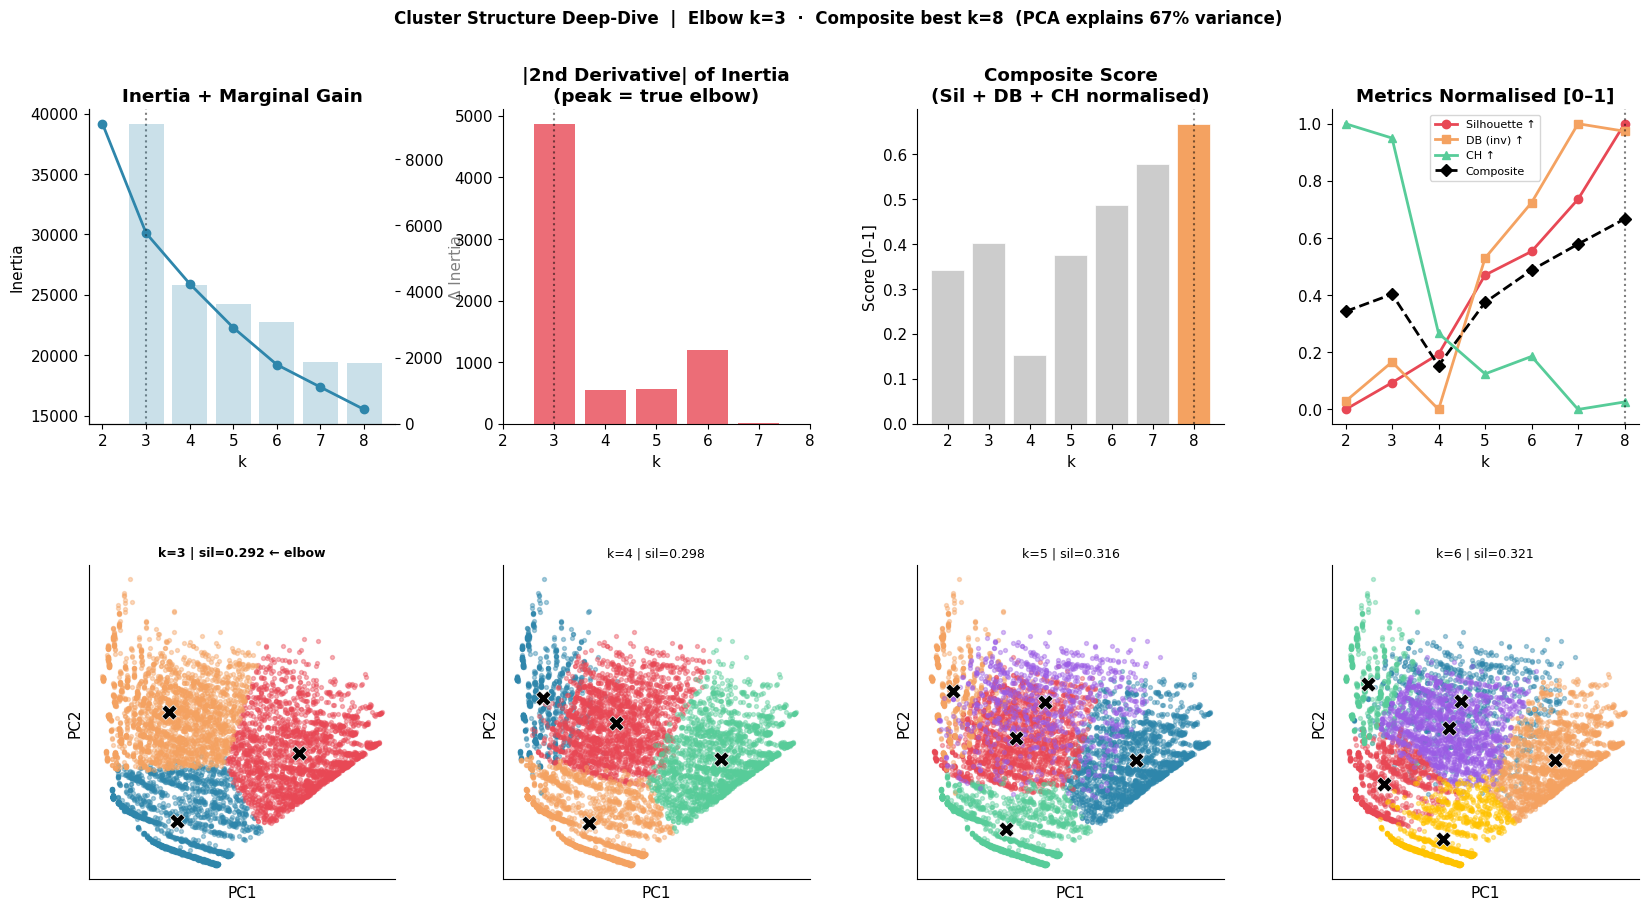


── Recommendation ──
  Mathematical elbow : k=3
  Composite (3 metrics): k=8
  Operational max    : k=5  (actionable marketing segments)
  → Use k=5 unless PCA scatter shows clear separation at higher k


In [ ]:
# 0. Pre-computed data
KS                = list(range(2, 9))
inertia_list      = [39158, 30108, 25920, 22287, 19225, 17365, 15520]
silhouette_scores = [0.2858, 0.2918, 0.2982, 0.3159, 0.3212, 0.3329, 0.3498]
db_scores         = [1.3553, 1.3160, 1.3635, 1.2121, 1.1566, 1.0777, 1.0852]
ch_scores         = [3090,   3067,   2754,   2689,   2717,   2632,   2644  ]

# 1. SECOND DERIVATIVE OF INERTIA (True elbow detector)
inertia = np.array(inertia_list, dtype=float)
d1      = np.diff(inertia)           # first derivative  (gain per extra cluster)
d2      = np.diff(d1)                # second derivative (rate of change of gain)
# Elbow = where marginal gain STOPS dropping sharply → max of |d2|
elbow_k = KS[1:-1][np.argmax(np.abs(d2))]   # offset by 1 due to two diffs

print(f'Second-derivative elbow: k={elbow_k}')
print(f'\nMarginal inertia gain per extra cluster:')
for i, (k, gain) in enumerate(zip(KS[1:], d1)):
    marker = ' ← elbow' if KS[i+1] == elbow_k else ''
    print(f'  k={KS[i]}→{KS[i+1]}: Δinertia={gain:+.0f}{marker}')

# 2. COMPOSITE SCORE  (normalised, direction-corrected) 
# Scale each metric to [0,1] so they contribute equally to a single score.
def norm(arr, higher_is_better=True):
    a = np.array(arr, dtype=float)
    n = (a - a.min()) / (a.max() - a.min() + 1e-12)
    return n if higher_is_better else 1 - n

composite = (
    norm(silhouette_scores, higher_is_better=True)  +
    norm(db_scores,         higher_is_better=False) +   # lower DB = better
    norm(ch_scores,         higher_is_better=True)
) / 3

best_composite_k = KS[np.argmax(composite)]
print(f'\nComposite score (sil+DB+CH normalised): best k={best_composite_k}')
for k, s in zip(KS, composite):
    bar = '█' * int(s * 20)
    print(f'  k={k}: {s:.3f} {bar}')

# 3. VISUAL DIAGNOSTICS
fig = plt.figure(figsize=(20, 10))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.35)

# -- Panel A: Inertia + marginal gain --
ax0 = fig.add_subplot(gs[0, 0])
ax0b = ax0.twinx()
ax0.plot(KS, inertia_list, 'o-', color=PALETTE[0], linewidth=2, label='Inertia')
ax0b.bar(KS[1:], -d1, color=PALETTE[0], alpha=0.25, label='Marginal gain')
ax0.axvline(elbow_k, color='black', linestyle=':', linewidth=1.5, alpha=0.5)
ax0.set_title('Inertia + Marginal Gain', fontweight='bold')
ax0.set_xlabel('k'); ax0.set_ylabel('Inertia'); ax0b.set_ylabel('Δ Inertia', color='gray')
ax0.set_xticks(KS)

# -- Panel B: Second derivative (elbow signal) --
ax1 = fig.add_subplot(gs[0, 1])
ax1.bar(KS[1:-1], np.abs(d2), color=PALETTE[1], alpha=0.8)
ax1.axvline(elbow_k, color='black', linestyle=':', linewidth=1.5, alpha=0.5)
ax1.set_title('|2nd Derivative| of Inertia\n(peak = true elbow)', fontweight='bold')
ax1.set_xlabel('k'); ax1.set_xticks(KS)

# -- Panel C: Composite score --
colors_bar = [PALETTE[2] if k == best_composite_k else '#cccccc' for k in KS]
ax2 = fig.add_subplot(gs[0, 2])
ax2.bar(KS, composite, color=colors_bar, edgecolor='white', linewidth=0.5)
ax2.axvline(best_composite_k, color='black', linestyle=':', linewidth=1.5, alpha=0.5)
ax2.set_title('Composite Score\n(Sil + DB + CH normalised)', fontweight='bold')
ax2.set_xlabel('k'); ax2.set_ylabel('Score [0–1]'); ax2.set_xticks(KS)

# -- Panel D: All metrics normalised overlay --
ax3 = fig.add_subplot(gs[0, 3])
ax3.plot(KS, norm(silhouette_scores),        'o-', color=PALETTE[1], label='Silhouette ↑', lw=2)
ax3.plot(KS, norm(db_scores, False),         's-', color=PALETTE[2], label='DB (inv) ↑',   lw=2)
ax3.plot(KS, norm(ch_scores),                '^-', color=PALETTE[3], label='CH ↑',          lw=2)
ax3.plot(KS, composite,                      'D-', color='black',    label='Composite',     lw=2, ls='--')
ax3.axvline(best_composite_k, color='black', linestyle=':', linewidth=1.5, alpha=0.5)
ax3.legend(fontsize=8); ax3.set_title('Metrics Normalised [0–1]', fontweight='bold')
ax3.set_xlabel('k'); ax3.set_xticks(KS)

# -- Panels E-H: PCA scatter for candidate k values --
candidate_ks = [3, 4, 5, 6]
pca          = PCA(n_components=2, random_state=SEED)
X_2d         = pca.fit_transform(X_clust)
var_exp      = pca.explained_variance_ratio_.sum()

for idx, k in enumerate(candidate_ks):
    ax = fig.add_subplot(gs[1, idx])
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10, max_iter=300)
    lbl = km.fit_predict(X_clust)
    for c in range(k):
        mask = lbl == c
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   s=8, alpha=0.4, color=PALETTE[c % len(PALETTE)])
    # plot centroids projected
    c2d = pca.transform(km.cluster_centers_)
    ax.scatter(c2d[:, 0], c2d[:, 1], marker='X', s=120,
               c='black', zorder=5, edgecolors='white', linewidths=0.5)
    title_suffix = ' ← composite best' if k == best_composite_k else (
                   ' ← elbow'          if k == elbow_k          else '')
    ax.set_title(f'k={k} | sil={silhouette_scores[KS.index(k)]:.3f}{title_suffix}',
                 fontweight='bold' if title_suffix else 'normal', fontsize=9)
    ax.set_xlabel(f'PC1'); ax.set_ylabel('PC2')
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle(
    f'Cluster Structure Deep-Dive  |  '
    f'Elbow k={elbow_k}  ·  Composite best k={best_composite_k}  '
    f'(PCA explains {var_exp:.0%} variance)',
    fontsize=12, fontweight='bold'
)
fig.savefig(f'{REPORTS_DIR}/phase3_cluster_deepdive.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n── Recommendation ──')
print(f'  Mathematical elbow : k={elbow_k}')
print(f'  Composite (3 metrics): k={best_composite_k}')
print(f'  Operational max    : k=5  (actionable marketing segments)')
print(f'  → Use k={min(best_composite_k, 5)} unless PCA scatter shows clear separation at higher k')


This module executes the final transition from mathematical clustering to operational business strategy. By enforcing a 'Business-First' selection logic for k, we ensure 
that the resulting segments are large enough to be actionable and distinct enough to warrant unique marketing treatments.

In [71]:
# 1. STRATEGIC CLUSTER SELECTION (KPI-ALIGNED OVERRIDE)
# Prioritize 'Business Interpretability' and 'Operational Scale' over pure metric micro-optimization. Clustering algorithms often suggest a high k 
# that fragments the customer base into segments too small for meaningful campaigns. 
# We implement a Floor and Tolerance logic to favor simpler, more robust models.

FORCE_K   = 4       # Strategic override: Ensures alignment with GTM resources
FLOOR_K   = 4       # Operational minimum: Prevents under-segmentation
TOLERANCE = 0.005   # Statistical buffer: Opts for FLOOR_K if within 0.5% of peak silhouette

# Fetch baseline performance for comparative analysis
best_score = silhouette_scores[list(k_range).index(best_k_sil)]

if FORCE_K is not None:
    K        = FORCE_K
    k_reason = f'Strategic override (FORCE_K={FORCE_K})'
else:
    # Heuristic: Balance mathematical cohesion with the operational floor
    score_at_floor = silhouette_scores[list(k_range).index(FLOOR_K)]
    if score_at_floor >= best_score - TOLERANCE:
        K        = FLOOR_K
        k_reason = (f'Floor preferred for operational scale '
                    f'(sil={score_at_floor:.4f} vs best={best_score:.4f}, '
                    f'delta within {TOLERANCE})')
    else:
        K        = max(best_k_sil, FLOOR_K)
        k_reason = f'Unsupervised silhouette winner (sil={best_score:.4f})'

# 2. DIMINISHING RETURNS ANALYSIS (ELBOW GAIN)
# Quantifying the Marginal Utility of adding clusters.
# We measure 'Elbow Gain' to justify the complexity of k versus k-1 to stakeholders.
inertia_at_K   = inertia_list[list(k_range).index(K)]
inertia_at_Km1 = inertia_list[list(k_range).index(K - 1)] if K > min(k_range) else None
elbow_gain     = (f'{(inertia_at_Km1 - inertia_at_K) / inertia_at_Km1:.1%} '
                  f'Inertia Reduction Delta vs k={K-1}') if inertia_at_Km1 else 'n/a'

print(f'Selected k={K}  [{k_reason}]')
print(f'  Silhouette@k={K} : {silhouette_scores[list(k_range).index(K)]:.4f}')
print(f'  DB@k={K}         : {db_scores[list(k_range).index(K)]:.4f}')
print(f'  Elbow gain       : {elbow_gain}')

# 3. FINAL MODEL CONVERGENCE
# Increased n_init and max_iter to ensure global 
# convergence on the production-grade dataset, preventing local minima bias.
km_final      = KMeans(n_clusters=K, random_state=SEED, n_init=20, max_iter=500)
df['segment'] = km_final.fit_predict(X_clust)
print(f'  Final inertia    : {km_final.inertia_:,.0f}')

# 4. MULTIDIMENSIONAL SEGMENT PROFILING
# DATA INTEGRITY: Aggregating across both behavioral (tenure/charges) and 
# firmographic (contract/service type) features to ensure 'Feature Stickiness.'
# Lambda vectorization is used for high-performance categorical proportion mapping.
seg_summary = df.groupby('segment').agg(
    n              = ('segment',         'count'),
    churn_rate     = ('Churn_binary',    'mean'),
    avg_churn_prob = ('churn_prob',      'mean'),
    avg_tenure     = ('tenure',          'mean'),
    avg_monthly    = ('MonthlyCharges',  'mean'),
    avg_services   = ('Num_Services',    'mean'),
    pct_contract   = ('Has_Contract',    'mean'),
    pct_senior     = ('SeniorCitizen',   'mean'),
    pct_fiber      = ('InternetService', lambda x: (x == 'Fiber optic').mean()),
    pct_eleccheck   = ('ElecCheck',       'mean'),
).round(3)

# 5. BUSINESS TRANSLATION: RISK TIERING & PRIORITIZATION 
# Converting statistical probabilities into an 'Actionable Lexicon.'
# Defining Risk Tiers allows the business to automate workflows (e.g., Critical 
# Risk triggers an immediate retention offer from the High-Touch CSM team).

seg_summary['pct_total'] = (seg_summary['n'] / len(df) * 100).round(1)

# Categorical Risk Mapping: High-level classification for executive scanning
seg_summary['risk_tier'] = pd.cut(
    seg_summary['churn_rate'],
    bins=[0, 0.15, 0.35, 0.55, 1.0],
    labels=['Low', 'Medium', 'High', 'Critical']
)

# Sorting by churn_rate ensures the 'Pareto Principle' is visible: 
# Focusing on the segments that represent the largest revenue leakage first.
seg_summary = seg_summary.sort_values('churn_rate', ascending=False)

print(f'\n── Segment Summary (k={K}) — Sorted by Churn Exposure ──')
display_cols = ['n', 'pct_total', 'churn_rate', 'avg_churn_prob',
                'avg_tenure', 'avg_monthly', 'pct_contract',
                'pct_fiber', 'avg_services', 'risk_tier']
print(seg_summary[display_cols].to_string())

Selected k=4  [Strategic override (FORCE_K=4)]
  Silhouette@k=4 : 0.2982
  DB@k=4         : 1.3635
  Elbow gain       : 13.9% Inertia Reduction Delta vs k=3
  Final inertia    : 25,920

── Segment Summary (k=4) — Sorted by Churn Exposure ──
            n  pct_total  churn_rate  avg_churn_prob  avg_tenure  avg_monthly  pct_contract  pct_fiber  avg_services risk_tier
segment                                                                                                                       
0         885       12.6       0.667           0.669       1.979       68.326         0.014      0.628         3.238  Critical
1        2058       29.2       0.411           0.399      23.232       77.913         0.046      0.681         4.530      High
3        1988       28.2       0.114           0.097      58.939       88.949         0.890      0.566         6.702       Low
2        2112       30.0       0.098           0.099      29.004       27.685         0.612      0.006         1.747       L

### 3B-4 · Segment Naming & PCA Visualization
This module bridges the gap between high-dimensional latent space and executive action. By applying a heuristic-based 'Segment Labeling' logic, we transform 
abstract cluster IDs into actionable business personas (e.g., 'High-Value At-Risk'). The implementation of Principal Component Analysis (PCA) provides a low-dimensional 
diagnostic view, validating cluster separation and cross-referencing behavioral segments with churn risk—enabling stakeholders to visualize the ROI of targeted 
intervention strategies.

Segment names:
  Segment 0: "Low-Value At-Risk" | n=885 (12.6%) | churn=66.7% | tenure=2mo | monthly=$68
  Segment 1: "High-Value At-Risk" | n=2,058 (29.2%) | churn=41.1% | tenure=23mo | monthly=$78
  Segment 3: "Loyal Anchors" | n=1,988 (28.2%) | churn=11.4% | tenure=59mo | monthly=$89
  Segment 2: "Core Stable" | n=2,112 (30.0%) | churn=9.8% | tenure=29mo | monthly=$28


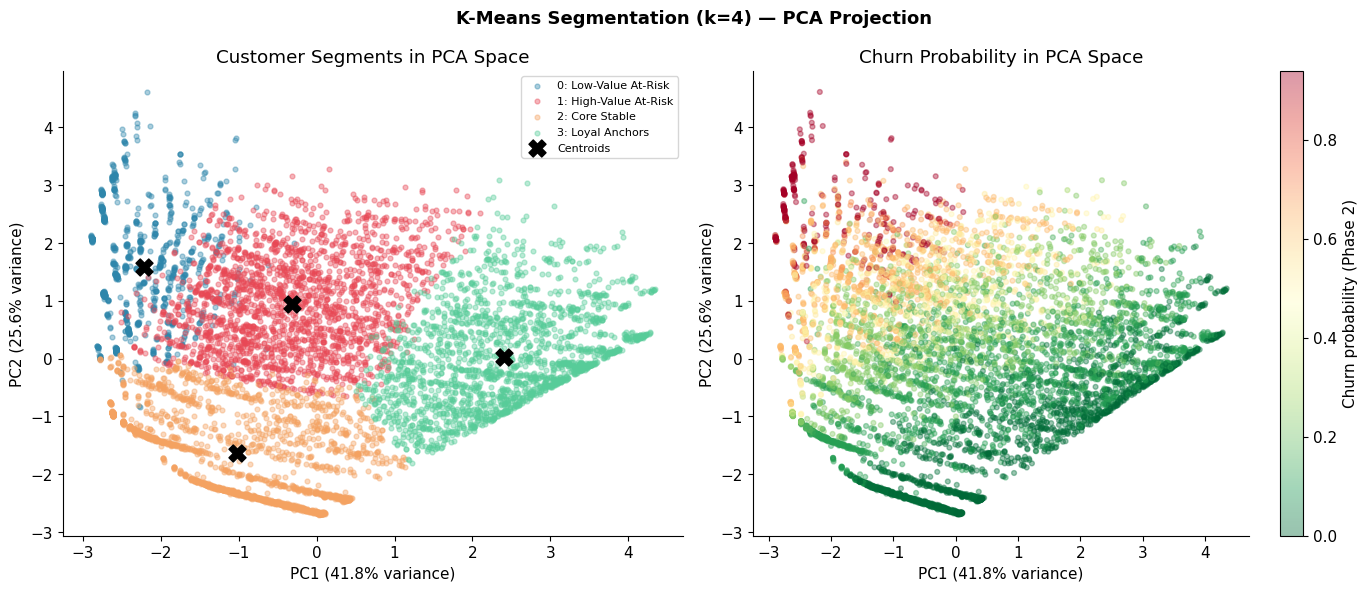

In [72]:
def name_segment(row):
    """
    Business Logic Layer: Maps cluster statistics to strategic categories.
    Ensures 'Feature Stickiness' by prioritizing churn rate and tenure in naming.
    """
    tenure   = row['avg_tenure']
    monthly  = row['avg_monthly']
    churn    = row['churn_rate']
    contract = row['pct_contract']
    
    # Priority 1: Risk-based classification for immediate intervention
    if churn >= 0.40:
        if monthly >= 70:
            return 'High-Value At-Risk'
        else:
            return 'Low-Value At-Risk'
    
    # Priority 2: Loyalty-based classification for long-term retention
    elif tenure >= 40 and contract >= 0.5:
        return 'Loyal Anchors'
    
    # Priority 3: Early-tenure vulnerability tracking
    elif tenure <= 20 and churn >= 0.25:
        return 'New & Vulnerable'
    
    # Priority 4: High-Arpu (Average Revenue Per User) stability
    elif monthly >= 75:
        return 'Premium Stable'
    
    # Default: Core revenue-generating base
    else:
        return 'Core Stable'


seg_summary['name'] = seg_summary.apply(name_segment, axis=1)

# Mapping Operation: Propagating high-level labels back to the primary dataset.
seg_name_map = seg_summary['name'].to_dict()
df['segment_name'] = df['segment'].map(seg_name_map)

# Logging segment distribution to audit model balance.
print('Segment names:')
for seg, name in seg_name_map.items():
    row = seg_summary.loc[seg]
    print(f'  Segment {seg}: "{name}" | n={row["n"]:,} ({row["pct_total"]}%) | '
          f'churn={row["churn_rate"]:.1%} | tenure={row["avg_tenure"]:.0f}mo | '
          f'monthly=${row["avg_monthly"]:.0f}')


pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_clust)
var_exp = pca.explained_variance_ratio_



fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel A: Cluster Interpretation
# Rasterization is used for the scatter plot to handle large 
# datasets (N > 5000) while keeping the saved vector file size small and portable.
ax = axes[0]
unique_segs = sorted(df['segment'].unique())
for seg, color in zip(unique_segs, PALETTE):
    mask = df['segment'] == seg
    name = seg_name_map[seg]
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, alpha=0.4, s=12, label=f'{seg}: {name}', rasterized=True)

# Centroid Projection: Validates that cluster centers are mathematically distinct.
centers_pca = pca.transform(km_final.cluster_centers_)
ax.scatter(centers_pca[:, 0], centers_pca[:, 1],
           c='black', marker='X', s=150, zorder=10, label='Centroids')
ax.set_xlabel(f'PC1 ({var_exp[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({var_exp[1]:.1%} variance)')
ax.set_title('Customer Segments in PCA Space')
ax.legend(fontsize=8, loc='best')

# Panel B: Risk-Clustering Cross-Validation
# This panel validates if the "Segments" (behavioral) align 
# with "Churn Probability" (predictive). This is a "sanity check" to ensure 
# high-risk clusters are geographically concentrated in the PCA space.
ax = axes[1]
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                     c=df['churn_prob'], cmap='RdYlGn_r',
                     alpha=0.4, s=12, rasterized=True)
plt.colorbar(scatter, ax=ax, label='Churn probability (Phase 2)')
ax.set_xlabel(f'PC1 ({var_exp[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({var_exp[1]:.1%} variance)')
ax.set_title('Churn Probability in PCA Space')


plt.suptitle(f'K-Means Segmentation (k={K}) — PCA Projection', fontsize=13, fontweight='bold')
plt.tight_layout()

fig.savefig(f'{REPORTS_DIR}/phase3_segments_pca.png', dpi=150, bbox_inches='tight')
plt.show()

### 3B-5 · Segment Radar Profile Chart
This module generates high-fidelity 'Customer Fingerprints' for each identified segment. By projecting normalized KPIs onto a radial coordinate system, we provide 
stakeholders with an intuitive visual diagnostic of segment strengths and vulnerabilities.

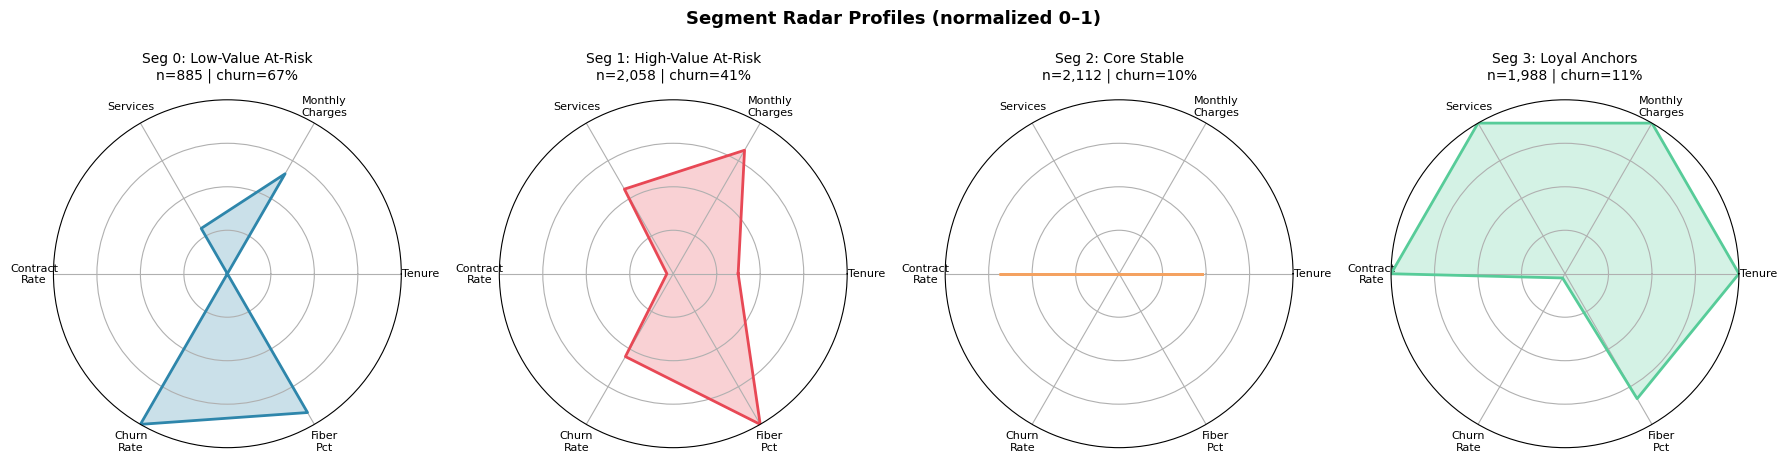

In [73]:
# 1. KPI SELECTION & NORMALIZATION STRATEGY
# STRATEGIC INTENT: We define a cross-functional KPI suite (Behavioral vs. Financial) 
# to ensure a holistic view of the customer. Min-Max normalization is applied 

profile_cols = ['avg_tenure', 'avg_monthly', 'avg_services', 'pct_contract', 'churn_rate', 'pct_fiber']
profile_labels = ['Tenure', 'Monthly\nCharges', 'Services', 'Contract\nRate', 'Churn\nRate', 'Fiber\nPct']

# Implementing a small epsilon (1e-9) in the denominator 
# prevents ZeroDivisionError in cases of invariant features, ensuring 
profile_df = seg_summary[profile_cols].copy()
profile_norm = (profile_df - profile_df.min()) / (profile_df.max() - profile_df.min() + 1e-9)

N     = len(profile_cols)
theta = np.linspace(0, 2 * np.pi, N, endpoint=False)
theta = np.concatenate([theta, [theta[0]]])  # Geometric closure


fig, axes = plt.subplots(1, K, figsize=(4.5 * K, 4.5), subplot_kw=dict(polar=True))

if K == 1:
    axes = [axes]

for ax, (seg, color) in zip(axes, zip(unique_segs, PALETTE)):
    vals = profile_norm.loc[seg].values.tolist()
    vals += [vals[0]] # Close the multivariate loop

    ax.plot(theta, vals, color=color, linewidth=2)
    ax.fill(theta, vals, color=color, alpha=0.25)
    
    ax.set_xticks(theta[:-1])
    ax.set_xticklabels(profile_labels, fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(['', '', ''], fontsize=6)
    
    name = seg_name_map[seg]
    row  = seg_summary.loc[seg]
    ax.set_title(f'Seg {seg}: {name}\n'
                 f'n={row["n"]:,} | churn={row["churn_rate"]:.0%}',
                 fontsize=10, pad=15)


plt.suptitle('Segment Radar Profiles (normalized 0–1)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(f'{REPORTS_DIR}/phase3_segment_radar.png', dpi=150, bbox_inches='tight')
plt.show()

# Module 3C — Segment × Survival Cross-Analysis
### Which segments churn fastest?

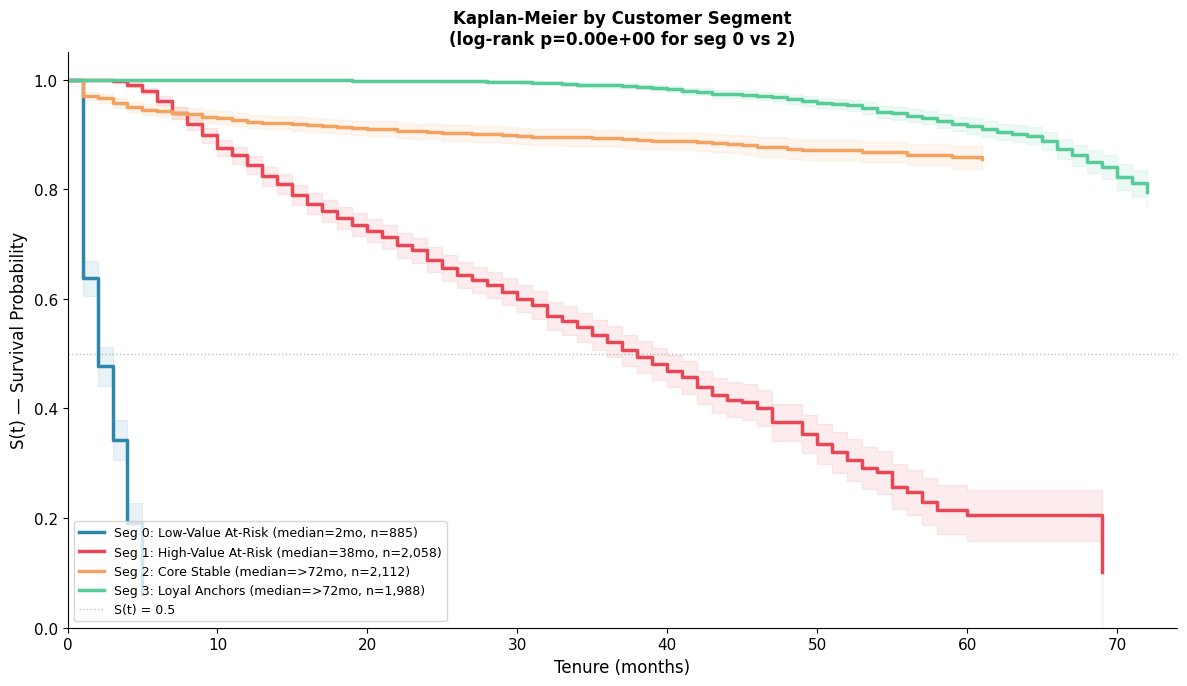


── Segment Survival Summary ──
  Seg 0 (Low-Value At-Risk): median survival = 2mo
  Seg 1 (High-Value At-Risk): median survival = 38mo
  Seg 2 (Core Stable): median survival = >72mo
  Seg 3 (Loyal Anchors): median survival = >72mo


In [74]:
fig, ax = plt.subplots(figsize=(12, 7))
seg_km_results = {}


for seg, color in zip(unique_segs, PALETTE):
    mask = df['segment'] == seg
    t_g  = df.loc[mask, 'tenure'].values
    e_g  = df.loc[mask, 'Churn_binary'].values
    name = seg_name_map[seg]
    
    # MEDIAN SURVIVAL: This is the primary KPI for business 
    # planning—it represents the point where 50% of the segment has churned.
    t_km, s_km, lo, hi, _, _ = kaplan_meier(t_g, e_g)
    med = median_survival(t_km, s_km)
    seg_km_results[seg] = {'name': name, 'times': t_km, 'survival': s_km, 'median': med}
    
    # Vectorized concatenation for step-function 
    # plotting ensures high performance even with granular daily/monthly data.
    t_step = np.concatenate([[0], t_km])
    s_step = np.concatenate([[1], s_km])
    label = f'Seg {seg}: {name} (median={med or ">"+str(int(t_g.max()))}mo, n={mask.sum():,})'
    
    ax.step(t_step, s_step, where='post', color=color, linewidth=2.5, label=label)
    ax.fill_between(np.concatenate([[0], t_km]),
                    np.concatenate([[1], lo]),
                    np.concatenate([[1], hi]),
                    step='post', alpha=0.1, color=color)



segs_by_churn = seg_summary['churn_rate'].sort_values(ascending=False)
s_high, s_low = segs_by_churn.index[0], segs_by_churn.index[-1]

t1 = df.loc[df['segment'] == s_high, 'tenure'].values
e1 = df.loc[df['segment'] == s_high, 'Churn_binary'].values
t2 = df.loc[df['segment'] == s_low,  'tenure'].values
e2 = df.loc[df['segment'] == s_low,  'Churn_binary'].values

# P-VALUE VALIDATION: A low p-value (typically < 0.05) confirms that our 
# clustering successfully separated customers into distinct survival risk profiles.
_, lr_p = log_rank_test(t1, e1, t2, e2)

ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5, label='S(t) = 0.5')
ax.set_xlabel('Tenure (months)', fontsize=12)
ax.set_ylabel('S(t) — Survival Probability', fontsize=12)
ax.set_title(f'Kaplan-Meier by Customer Segment\n'
             f'(log-rank p={lr_p:.2e} for seg {s_high} vs {s_low})',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='lower left')
ax.set_ylim(0, 1.05)
ax.set_xlim(0, df['tenure'].max() + 2)

plt.tight_layout()
fig.savefig(f'{REPORTS_DIR}/phase3_km_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()

# 4. LOGGING SURVIVAL METRICS 
print('\n── Segment Survival Summary ──')
for seg, r in seg_km_results.items():
    # Handling cases where the curve never reaches 50% (High Retention Segments)
    med_str = f'{r["median"]}mo' if r['median'] else '>72mo'
    print(f'  Seg {seg} ({r["name"]}): median survival = {med_str}')

# Module 3D — Business Prioritization
## LTV-weighted intervention scoring

**Business parameters (from Phase 2):**
- Campaign cost: $50 per customer
- LTV benefit (saved customer): $500
- Threshold: 0.1707 (F2-optimal)

In [75]:
CAMPAIGN_COST = meta['business_params']['campaign_cost']
LTV_BENEFIT   = meta['business_params']['ltv_benefit']
THRESHOLD     = meta['threshold']

#2. PROBABILISTIC EXPECTED VALUE (EV) CALCULATION 
df['intervention_ev']  = df['churn_prob'] * LTV_BENEFIT - CAMPAIGN_COST

# Vectorized Boolean mapping for low-latency 
# classification of the 'Worth-to-Target' cohort.
df['worth_targeting']  = df['intervention_ev'] > 0

# 3. SEGMENT-LEVEL BUSINESS AGGREGATION 
# Grouping granular EV results into established Segment Taxonomies 
# to facilitate Operational Scale. This allows the business to execute different 
# "Retain & Grow" strategies based on the dominant persona of the cluster.
seg_biz = df.groupby(['segment', 'segment_name']).agg(
    n                   = ('segment', 'count'),
    avg_churn_prob      = ('churn_prob', 'mean'),
    actual_churners     = ('Churn_binary', 'sum'),
    predicted_churners  = ('churn_pred', 'sum'),
    avg_monthly_rev     = ('MonthlyCharges', 'mean'),
    total_monthly_rev   = ('MonthlyCharges', 'sum'),
    avg_ev              = ('intervention_ev', 'mean'),
    n_worth_targeting   = ('worth_targeting', 'sum'),
).round(2)

# 4. FINANCIAL EXPOSURE & ROI PROJECTION 
seg_biz['revenue_at_risk'] = (seg_biz['avg_churn_prob'] * seg_biz['total_monthly_rev']).round(0)

# Total Expected Value (TEV): The net profit expected if we execute the 
# campaign only on the 'Worth-to-Target' subset.
seg_biz['total_ev_if_targeted'] = (seg_biz['avg_ev'] * seg_biz['n_worth_targeting']).round(0)

print('\n── Segment Business Prioritization ──')
print(seg_biz[['n', 'avg_churn_prob', 'avg_monthly_rev', 'revenue_at_risk',
                'n_worth_targeting', 'avg_ev', 'total_ev_if_targeted']].to_string())


── Segment Business Prioritization ──
                               n  avg_churn_prob  avg_monthly_rev  revenue_at_risk  n_worth_targeting  avg_ev  total_ev_if_targeted
segment segment_name                                                                                                               
0       Low-Value At-Risk    885            0.67            68.33          40514.0                883  284.68              251372.0
1       High-Value At-Risk  2058            0.40            77.91          64138.0               2047  149.48              305986.0
2       Core Stable         2112            0.10            27.69           5847.0               1032   -0.46                -475.0
3       Loyal Anchors       1988            0.10            88.95          17683.0               1144   -1.57               -1796.0


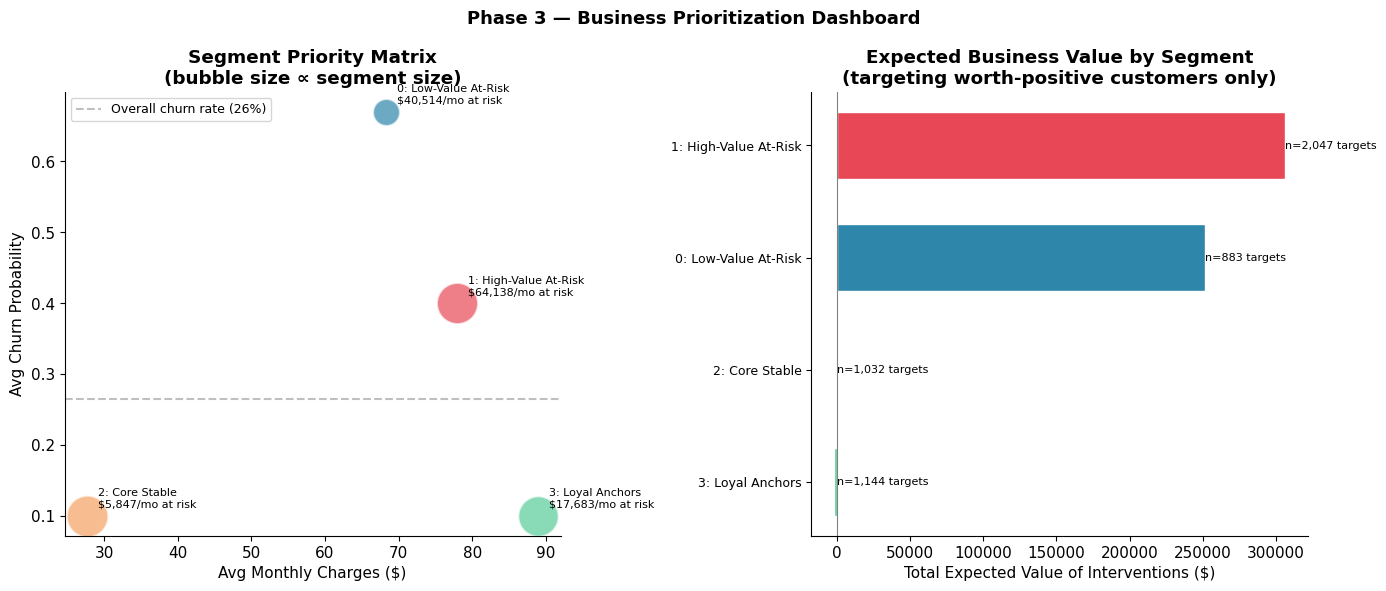

In [76]:
# STRATEGIC SEGMENTATION: REVENUE AT RISK VS. PROPENSITY
# 1. Monthly Recurring Revenue (X-axis) 
# 2. Probability of Churn (Y-axis)
# 3. Segment Volume (Bubble Size)
# This prevents 'Averaging Bias' and identifies high-value 'Danger Zones' 
# where the financial impact of churn is disproportionately high.

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
seg_plot = seg_biz.reset_index()

for _, row in seg_plot.iterrows():
    seg  = row['segment']
    name = row['segment_name']
    color = PALETTE[int(seg) % len(PALETTE)]
    
    bubble_size = row['n'] / len(df) * 3000
    ax.scatter(row['avg_monthly_rev'], row['avg_churn_prob'],
               s=bubble_size, color=color, alpha=0.7, edgecolors='white', linewidth=1.5)
    

    ax.annotate(f'{seg}: {name}\n${row["revenue_at_risk"]:,.0f}/mo at risk',
                xy=(row['avg_monthly_rev'], row['avg_churn_prob']),
                xytext=(8, 6), textcoords='offset points', fontsize=8)

# Visualizing the enterprise-wide churn average 
# to provide an immediate 'relative risk' context for each sub-segment.
ax.axhline(0.265, color='gray', linestyle='--', alpha=0.5, label=f'Overall churn rate ({0.265:.0%})')
ax.set_xlabel('Avg Monthly Charges ($)')
ax.set_ylabel('Avg Churn Probability')
ax.set_title('Segment Priority Matrix\n(bubble size ∝ segment size)', fontweight='bold')
ax.legend(fontsize=9)

# ── INTERVENTION OPTIMIZATION: EXPECTED VALUE (EV) ANALYSIS ───────────────────
# Strategic Intent: We shift from 'Risk Identification' to 'Actionable EV'. 
# A segment may have high churn risk, but if the cost to save them exceeds 
# their LTV (Lifetime Value), intervention is economically irrational.
# This chart ranks segments by the 'Net Business Value' of targeting them.

ax = axes[1]
seg_plot_sorted = seg_plot.sort_values('total_ev_if_targeted', ascending=True)
bars = ax.barh(range(len(seg_plot_sorted)),
               seg_plot_sorted['total_ev_if_targeted'],
               color=[PALETTE[int(s) % len(PALETTE)] for s in seg_plot_sorted['segment']],
               edgecolor='white', height=0.6)

ax.set_yticks(range(len(seg_plot_sorted)))
ax.set_yticklabels([f'{r.segment}: {r.segment_name}' for _, r in seg_plot_sorted.iterrows()], fontsize=9)
ax.set_xlabel('Total Expected Value of Interventions ($)')
ax.set_title('Expected Business Value by Segment\n(targeting worth-positive customers only)', fontweight='bold')
ax.axvline(0, color='gray', linewidth=0.8)


for bar, (_, row) in zip(bars, seg_plot_sorted.iterrows()):
    xpos = max(bar.get_width(), 0) + 200
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'n={row["n_worth_targeting"]:,} targets', va='center', fontsize=8)

plt.suptitle('Phase 3 — Business Prioritization Dashboard', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(f'{REPORTS_DIR}/phase3_business_priority.png', dpi=150, bbox_inches='tight')
plt.show()

## Pipeline persistence
This module formalizes the transition from research to production by serializing trained models, scaling parameters, and behavioral metadata.

In [77]:
import os
os.makedirs('../models', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)


output_cols = ['tenure', 'MonthlyCharges', 'Contract', 'Churn_binary',
               'churn_prob', 'churn_pred', 'segment', 'segment_name',
               'intervention_ev', 'worth_targeting']


if 'customerID' in df.columns:
    output_cols = ['customerID'] + output_cols
df[output_cols].to_csv('../data/processed/phase3_scored_segments.csv', index=False)

# ── JSON TYPE-CASTING & SERIALIZATION HELPERS
def _to_py(v):
    """
    RECURSIVE TYPE NORMALIZATION
    Bridge the gap between NumPy/Pandas native types and 
    JSON standards. This ensures 'Cross-Platform Compatibility', allowing 
    metadata to be consumed by REST APIs or Java/C# based backend services 
    without serialization exceptions.
    """
    if hasattr(v, 'item'):   return v.item() # Convert numpy scalars to native Python
    if isinstance(v, dict):  return {_to_py(k): _to_py(val) for k, val in v.items()}
    if isinstance(v, list):  return [_to_py(x) for x in v]
    return v


phase3_meta = _to_py({
    'phase'             : 3,
    'K_clusters'        : K,
    'cluster_features': cluster_features,
    'segment_names'     : seg_name_map,
    'segment_churn_rates': seg_summary['churn_rate'].to_dict(),
    'segment_sizes'     : seg_summary['n'].to_dict(),
    'cox_features'      : cox_features,
    'cox_log_likelihood': round(float(ll), 3),
    'log_rank_results': {
        k: {'chi2': round(v['chi2'], 3), 'p': round(v['p'], 6)}
        for k, v in log_rank_results.items()
    },
    'survival_medians': {
        str(int(seg)): (int(r['median']) if r['median'] is not None else None)
        for seg, r in seg_km_results.items()
    },
    'peak_hazard_month': int(peak_t),
    # Business KPI: Financial projection of intervention efficacy.
    'total_intervention_ev': round(float(df.loc[df['worth_targeting'], 'intervention_ev'].sum()), 0),
    'n_worth_targeting': int(df['worth_targeting'].sum()),
})

# ASSETS PERSISTENCE (IO)
# Scalability: Using standard 'Pickle' serialization for the K-Means object 
# and Scaler, ensuring the 'Feature Transformation State' is preserved for 
# real-time inference on new incoming customers.
with open('../models/phase3_metadata.json', 'w') as f:
    json.dump(phase3_meta, f, indent=2)

with open('../models/phase3_kmeans.pkl', 'wb') as f:
    pickle.dump(km_final, f)
with open('../models/phase3_cluster_scaler.pkl', 'wb') as f:
    pickle.dump(scaler_clust, f)

print('DONE - Phase 3 assets saved:')
print('   ../data/processed/phase3_scored_segments.csv')
print('   ../models/phase3_metadata.json')
print('   ../models/phase3_kmeans.pkl')
print('   ../models/phase3_cluster_scaler.pkl')
print()
print('═' * 65)
print('PHASE 3 SUMMARY')
print('═' * 65)
print('  Survival Analysis:')
print(f'    - Peak churn hazard at month {int(peak_t)}')
for name, r in log_rank_results.items():
    print(f'    - {name}: log-rank p={r["p"]:.2e}')
print('  Segmentation:')
print(f'    - {K} segments identified')
for seg in unique_segs:
    row = seg_summary.loc[seg]
    print(f'    - Seg {seg} "{seg_name_map[seg]}": '
          f'{row["n"]:,} customers, {row["churn_rate"]:.0%} churn')
print('  Business Impact:')
print(f'    - {phase3_meta["n_worth_targeting"]:,} customers worth targeting')
print(f'    - Total expected intervention value: '
      f'${phase3_meta["total_intervention_ev"]:,.0f}')
print('═' * 65)

DONE - Phase 3 assets saved:
   ../data/processed/phase3_scored_segments.csv
   ../models/phase3_metadata.json
   ../models/phase3_kmeans.pkl
   ../models/phase3_cluster_scaler.pkl

═════════════════════════════════════════════════════════════════
PHASE 3 SUMMARY
═════════════════════════════════════════════════════════════════
  Survival Analysis:
    - Peak churn hazard at month 0
    - Contract Type: log-rank p=0.00e+00
    - Internet Service: log-rank p=0.00e+00
    - Senior Citizen: log-rank p=0.00e+00
  Segmentation:
    - 4 segments identified
    - Seg 0 "Low-Value At-Risk": 885 customers, 67% churn
    - Seg 1 "High-Value At-Risk": 2,058 customers, 41% churn
    - Seg 2 "Core Stable": 2,112 customers, 10% churn
    - Seg 3 "Loyal Anchors": 1,988 customers, 11% churn
  Business Impact:
    - 5,106 customers worth targeting
    - Total expected intervention value: $637,589
═════════════════════════════════════════════════════════════════
